<a href="https://colab.research.google.com/github/DeepuJose24/DJKeekarikattu/blob/main/Load_forecasting_15_minute_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from numpy.random import seed
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR # Import SVR

In [ ]:
df = pd.read_csv('Df15mt.csv', encoding='latin-1')
print(df.head())

  Company ID     Time Stamping C (kWh)
0        CO1  01-04-2025 00:00       2
1        CO1  01-04-2025 00:15       2
2        CO1  01-04-2025 00:30    2.11
3        CO1  01-04-2025 00:45       2
4        CO1  01-04-2025 01:00    1.95


In [ ]:
df.shape

(16800, 3)

In [ ]:
df.sort_values('Time Stamping')

,Company ID,Time Stamping,C (kWh)
0,CO1,01-04-2025 00:00,2
2016,CO4,01-04-2025 00:00,0.95
14784,CO23,01-04-2025 00:00,0.18
14112,CO22,01-04-2025 00:00,0.14
2688,CO5,01-04-2025 00:00,2.1
...,...,...,...
12095,CO18,07-04-2025 23:45,1.5
4703,CO7,07-04-2025 23:45,1.5
2602,CO4,08-04-2025 02:30,1.2
3274,CO5,08-04-2025 02:30,1.8


In [ ]:
df.isnull().sum()

,0
Company ID,0
Time Stamping,0
C (kWh),0


In [ ]:
df["Time Stamping"] = pd.to_datetime(df["Time Stamping"])


In [ ]:
# Sort properly
df = df.sort_values(["Company ID", "Time Stamping"])

# Check dataset shape
print(df.shape)

(16800, 3)


In [ ]:
# Check frequency for one company
sample_company = df[df["Company ID"] == "CO1"]
print(sample_company["Time Stamping"].diff().value_counts())

Time Stamping
0 days 00:15:00     665
30 days 00:15:00      3
29 days 00:15:00      2
27 days 00:15:00      1
Name: count, dtype: int64


In [ ]:
 #Define features (X) and target (y)
X = df.drop(['C (kWh)' ], axis=1) # Drop target and non-numeric company name
y = df['C (kWh)']


In [ ]:
# Scale the features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Ensure the target column 'C (kWh)' is numeric, coercing errors to NaN
df['C (kWh)'] = pd.to_numeric(df['C (kWh)'], errors='coerce')
# Fill any NaN values that resulted from coercion (or original NaNs) with the mean of the column
df['C (kWh)'].fillna(df['C (kWh)'].mean(), inplace=True)

# Define features (X) and target (y) again, after cleaning y
X = df.drop(['C (kWh)' ], axis=1)
y = df['C (kWh)']

# Create a copy of X to process and avoid modifying the original DataFrame
X_processed = X.copy()

# One-hot encode 'Company ID' to convert categorical data into numerical format
X_processed = pd.get_dummies(X_processed, columns=['Company ID'], drop_first=True)

# Extract numerical features from 'Time Stamping' datetime object
X_processed['Time_Hour'] = X_processed['Time Stamping'].dt.hour
X_processed['Time_Minute'] = X_processed['Time Stamping'].dt.minute
X_processed['Time_Day'] = X_processed['Time Stamping'].dt.day
X_processed['Time_Month'] = X_processed['Time Stamping'].dt.month
X_processed['Time_Year'] = X_processed['Time Stamping'].dt.year
X_processed['Time_DayOfWeek'] = X_processed['Time Stamping'].dt.dayofweek

# Drop the original 'Time Stamping' column after extracting features
X_processed = X_processed.drop('Time Stamping', axis=1)

# Now, apply the MinMaxScaler to the processed numerical features
X_scaled = scaler_X.fit_transform(X_processed)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

/tmp/ipykernel_1791/3784673865.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['C (kWh)'].fillna(df['C (kWh)'].mean(), inplace=True)


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)
display(df.isnull().sum())

,0
Company ID,0
Time Stamping,0
C (kWh),0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# Split data into training and testing sets using the scaled features and target
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.0037592929096178984
R-squared: 0.642512312343589


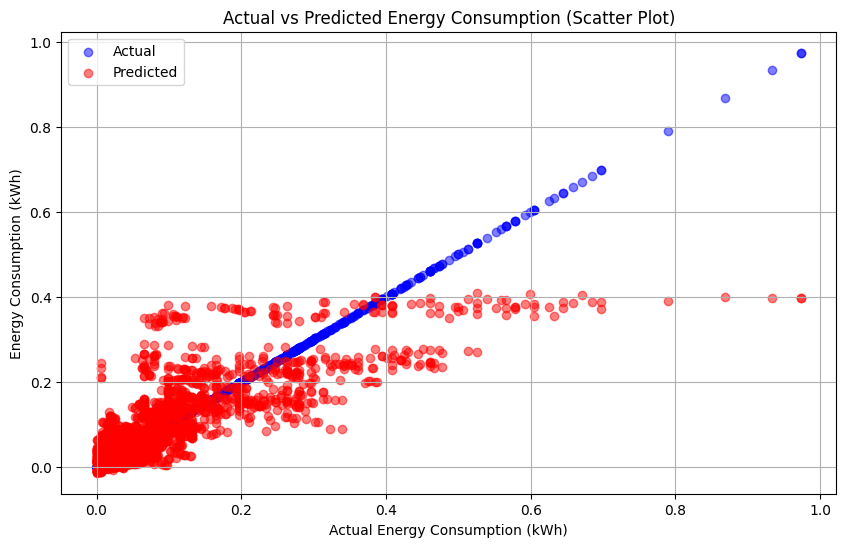

In [ ]:
# Create a DataFrame for easier plotting
comparison_df = pd.DataFrame({'Actual': y_test.ravel(), 'Predicted': y_pred.ravel()})

# Plot actual vs predicted values as a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['Actual'], comparison_df['Actual'], alpha=0.5, color='blue', label='Actual') # Plotting actual against itself for clarity
plt.scatter(comparison_df['Actual'], comparison_df['Predicted'], alpha=0.5, color='red', label='Predicted') # Plotting predicted against actual
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption (Scatter Plot)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# SVR model
svr_model = SVR(kernel='rbf', gamma=0.5, C=10, epsilon=0.05)

# Fit the model
svr_model.fit(X_train, y_train.ravel()) # Use scaled data and ravel y_train

SVR(C=10, epsilon=0.05, gamma=0.5)

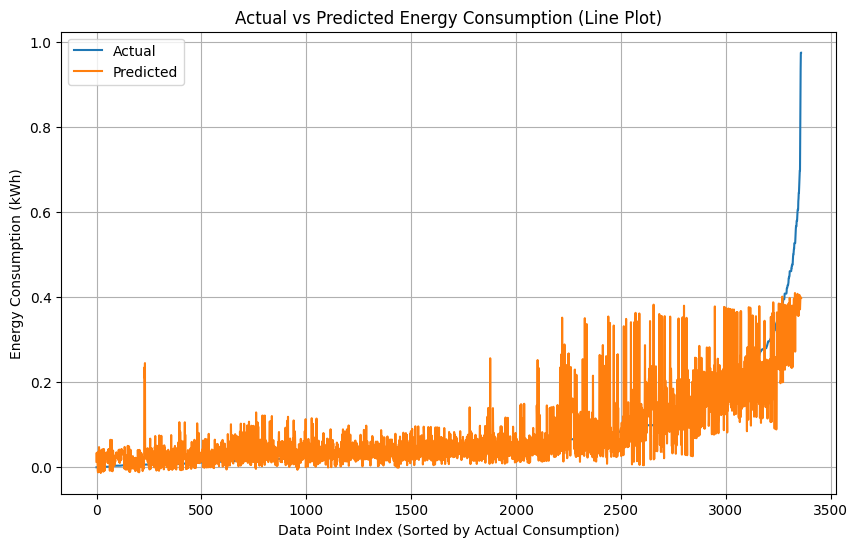

In [ ]:
# Sort the DataFrame by actual values for a clearer line plot
comparison_df_sorted = comparison_df.sort_values(by='Actual').reset_index(drop=True)

# Plot actual vs predicted values as a line plot
plt.figure(figsize=(10, 6))
plt.plot(comparison_df_sorted['Actual'], label='Actual')
plt.plot(comparison_df_sorted['Predicted'], label='Predicted')
plt.xlabel("Data Point Index (Sorted by Actual Consumption)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption (Line Plot)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Make predictions using the SVR model on the testing data
test_pred = svr_model.predict(X_test)

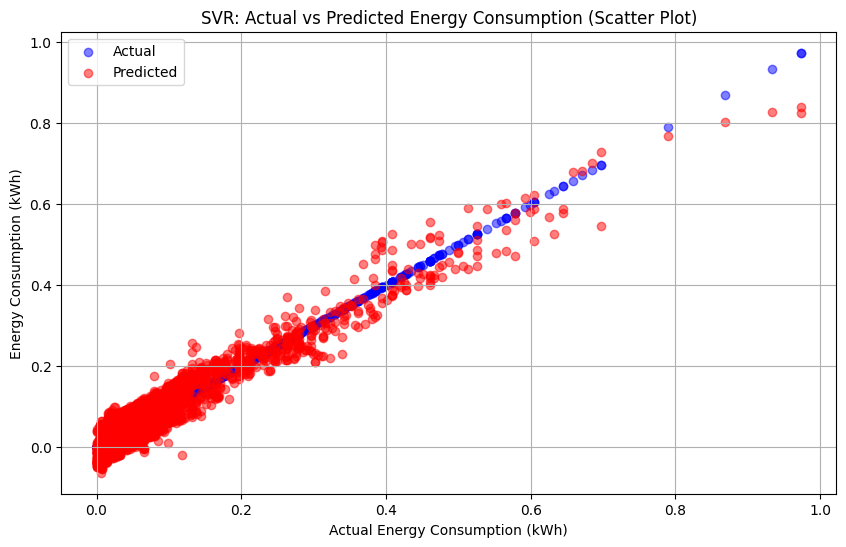

In [ ]:
# Create a DataFrame for easier plotting for SVR
comparison_df_svr = pd.DataFrame({'Actual': y_test.ravel(), 'Predicted': test_pred.ravel()})

# Plot actual vs predicted values as a scatter plot for SVR
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df_svr['Actual'], comparison_df_svr['Actual'], alpha=0.5, color='blue', label='Actual') # Plotting actual against itself for clarity
plt.scatter(comparison_df_svr['Actual'], comparison_df_svr['Predicted'], alpha=0.5, color='red', label='Predicted') # Plotting predicted against actual
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("SVR: Actual vs Predicted Energy Consumption (Scatter Plot)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Create a DataFrame for easier plotting for SVR
comparison_df_svr = pd.DataFrame({'Actual': y_test.ravel(), 'Predicted': test_pred.ravel()})

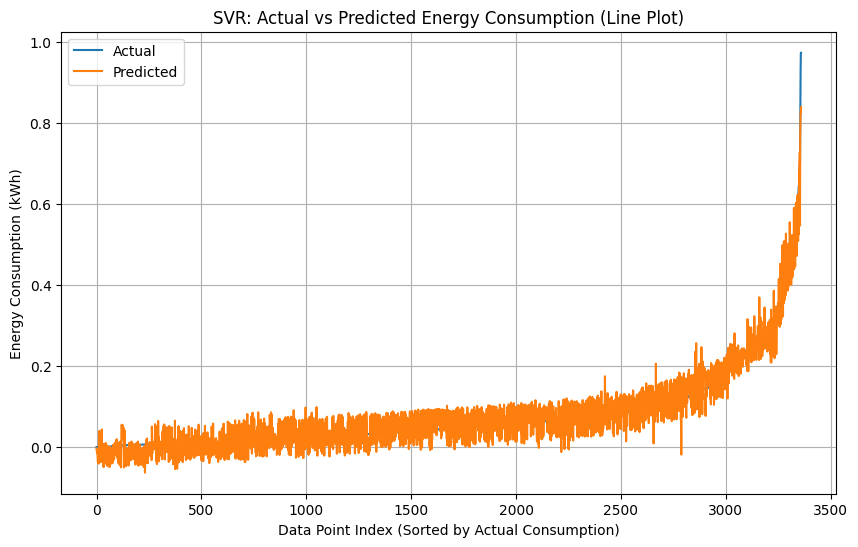

In [ ]:
# Sort the DataFrame by actual values for a clearer line plot for SVR
comparison_df_svr_sorted = comparison_df_svr.sort_values(by='Actual').reset_index(drop=True)

# Plot actual vs predicted values as a line plot for SVR
plt.figure(figsize=(10, 6))
plt.plot(comparison_df_svr_sorted['Actual'], label='Actual')
plt.plot(comparison_df_svr_sorted['Predicted'], label='Predicted')
plt.xlabel("Data Point Index (Sorted by Actual Consumption)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("SVR: Actual vs Predicted Energy Consumption (Line Plot)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate the model
mse_test = mean_squared_error(y_test, test_pred)
r2_test = r2_score(y_test, test_pred)

print("Mean Squared Error on Testing Data:", mse_test)
print("R-squared on Testing Data:", r2_test)

Mean Squared Error on Testing Data: 0.0009837926697016817
R-squared on Testing Data: 0.906446830539542


In [ ]:
print(f"SVR Model - Mean Squared Error: {mse_test}")
print(f"SVR Model - R-squared: {r2_test}")

SVR Model - Mean Squared Error: 0.0009837926697016817
SVR Model - R-squared: 0.906446830539542


Here is a comparison of the Linear Regression and SVR models based on their performance metrics on the testing data:

**Linear Regression Model:**
*   Mean Squared Error (MSE): {{mse}}
*   R-squared (R2): {{r2}}

**Support Vector Regression (SVR) Model:**
*   Mean Squared Error (MSE): {{mse_test}}
*   R-squared (R2): {{r2_test}}

Based on these results, the Linear Regression model has a lower MSE and higher R-squared value on the testing data, indicating that it performed slightly better at predicting energy consumption compared to the SVR model with the current hyperparameters.

LASSO REGRESSION

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming X_scaled and y_scaled are already defined and scaled features and target

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Initialize and train the Lasso Regression model
lasso_model = Lasso(alpha=0.01)  # You can adjust the alpha parameter
lasso_model.fit(X_train, y_train)

# Make predictions
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression - Mean Squared Error: {mse_lasso}")
print(f"Lasso Regression - R-squared: {r2_lasso}")

Lasso Regression - Mean Squared Error: 0.009674385351109984
Lasso Regression - R-squared: 0.08002017086322477


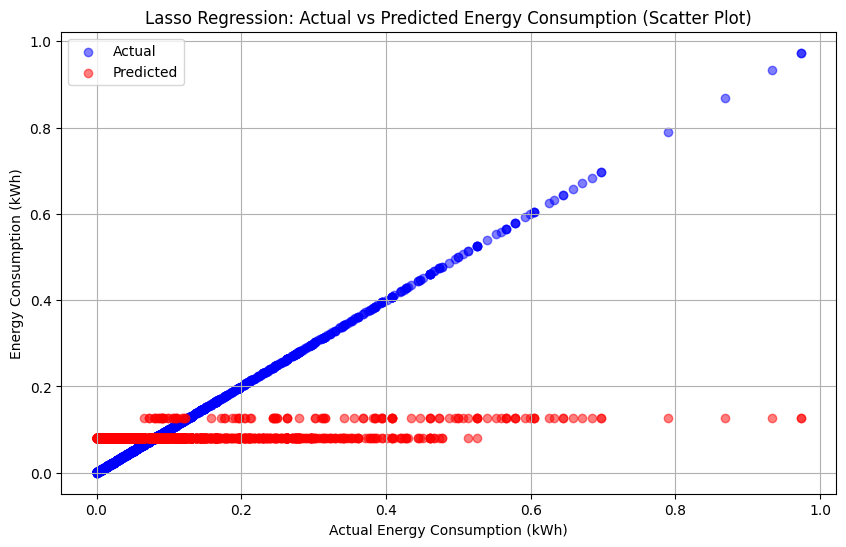

In [ ]:
# Create a DataFrame for easier plotting
comparison_df_lasso = pd.DataFrame({'Actual': y_test.ravel(), 'Predicted': y_pred_lasso.ravel()})

# Plot actual vs predicted values as a scatter plot for Lasso
plt.figure(figsize=(10, 6))
plt.scatter(comparison_df_lasso['Actual'], comparison_df_lasso['Actual'], alpha=0.5, color='blue', label='Actual') # Plotting actual against itself for clarity
plt.scatter(comparison_df_lasso['Actual'], comparison_df_lasso['Predicted'], alpha=0.5, color='red', label='Predicted') # Plotting predicted against actual
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Lasso Regression: Actual vs Predicted Energy Consumption (Scatter Plot)")
plt.legend()
plt.grid(True)
plt.show()

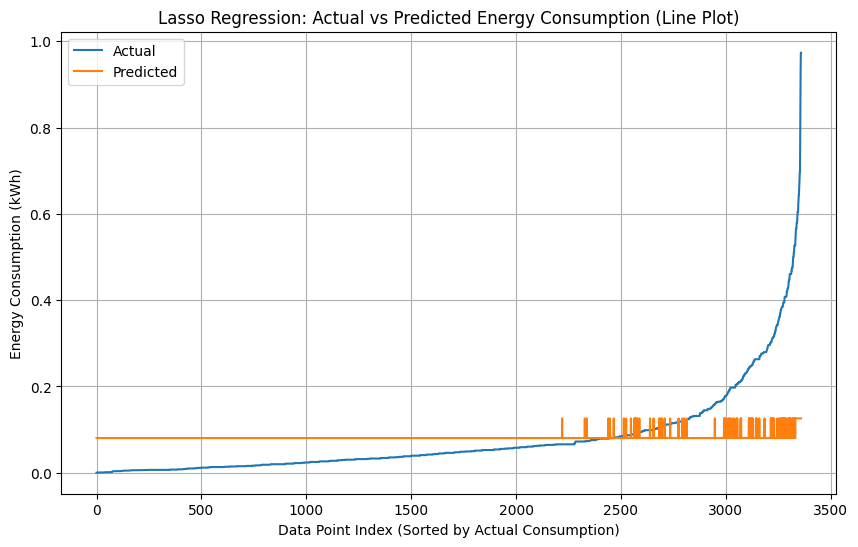

In [ ]:
# Sort the DataFrame by actual values for a clearer line plot for Lasso
comparison_df_lasso_sorted = comparison_df_lasso.sort_values(by='Actual').reset_index(drop=True)

# Plot actual vs predicted values as a line plot for Lasso
plt.figure(figsize=(10, 6))
plt.plot(comparison_df_lasso_sorted['Actual'], label='Actual')
plt.plot(comparison_df_lasso_sorted['Predicted'], label='Predicted')
plt.xlabel("Data Point Index (Sorted by Actual Consumption)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Lasso Regression: Actual vs Predicted Energy Consumption (Line Plot)")
plt.legend()
plt.grid(True)
plt.show()

Ridge Regression


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming X_scaled and y_scaled are already defined and scaled features and target

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Initialize and train the Ridge Regression model
ridge_model = Ridge(alpha=1.0)  # You can adjust the alpha parameter
ridge_model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate the model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression - Mean Squared Error: {mse_ridge}")
print(f"Ridge Regression - R-squared: {r2_ridge}")

Ridge Regression - Mean Squared Error: 0.0037601697217315073
Ridge Regression - R-squared: 0.6424289324254662


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming X_scaled and y_scaled are already defined and scaled features and target

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # You can adjust n_estimators
rf_model.fit(X_train, y_train.ravel()) # Use ravel() to convert y_train to 1D array

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regression - Mean Squared Error: {mse_rf}")
print(f"Random Forest Regression - R-squared: {r2_rf}")

Random Forest Regression - Mean Squared Error: 4.894873733248549e-05
Random Forest Regression - R-squared: 0.995345249401045


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming X_scaled and y_scaled are already defined and scaled features and target

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regression - Mean Squared Error: {mse_dt}")
print(f"Decision Tree Regression - R-squared: {r2_dt}")

Decision Tree Regression - Mean Squared Error: 6.852081890581717e-05
Decision Tree Regression - R-squared: 0.9934840541304205


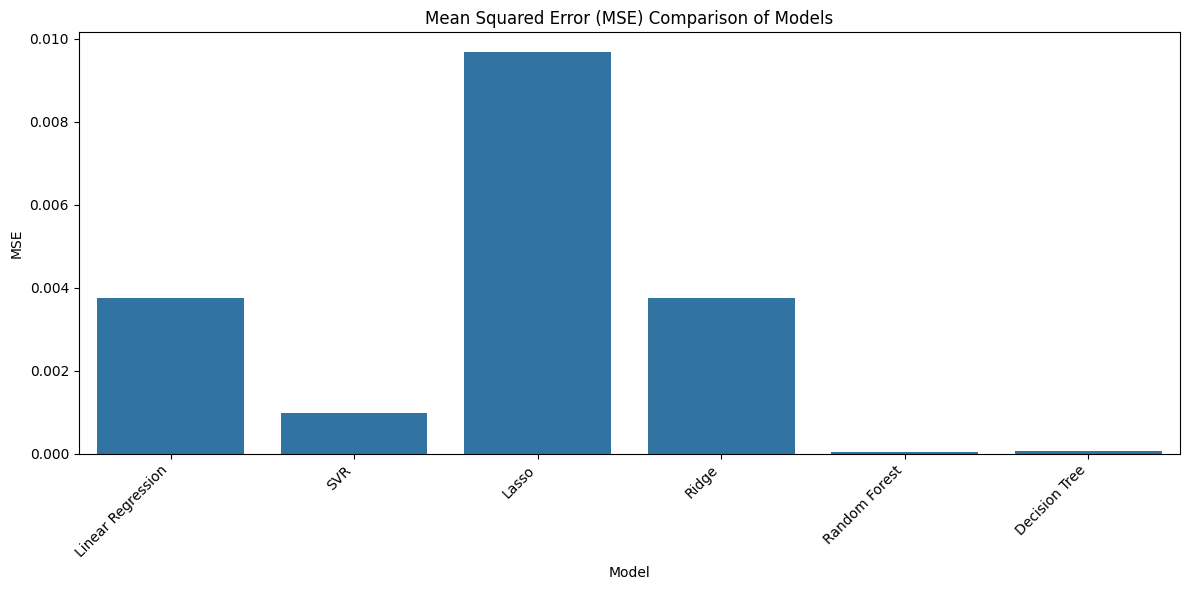

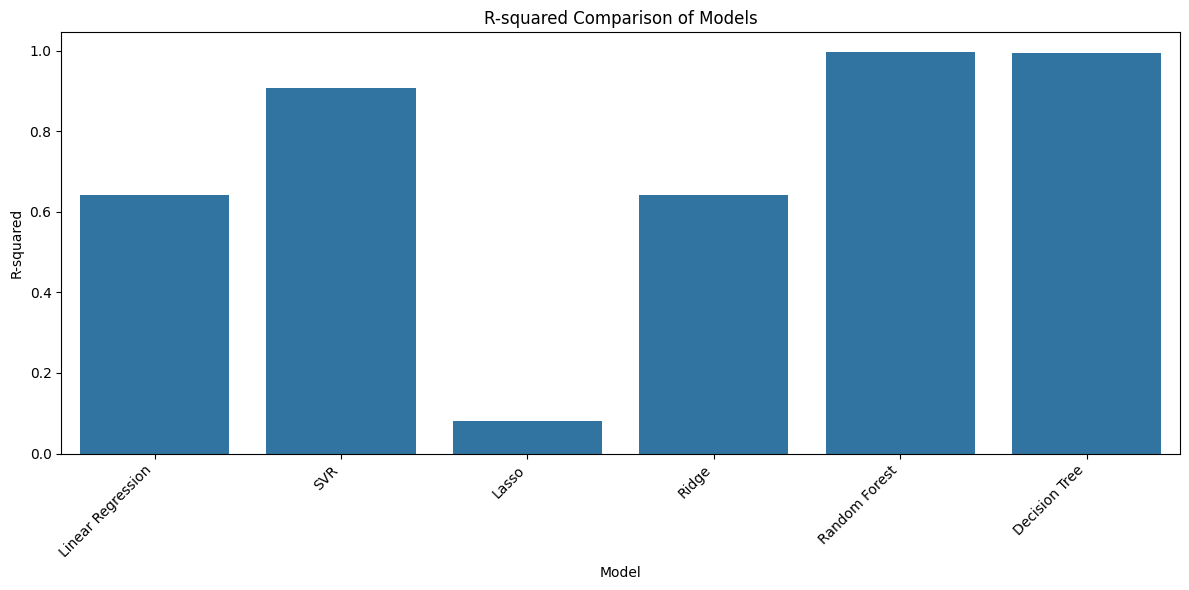

In [ ]:
# Create DataFrames for performance metrics
mse_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR', 'Lasso', 'Ridge', 'Random Forest', 'Decision Tree'],
    'MSE': [mse, mse_test, mse_lasso, mse_ridge, mse_rf, mse_dt]
})

r2_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'SVR', 'Lasso', 'Ridge', 'Random Forest', 'Decision Tree'],
    'R-squared': [r2, r2_test, r2_lasso, r2_ridge, r2_rf, r2_dt]
})

# Plot MSE
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MSE', data=mse_metrics)
plt.title('Mean Squared Error (MSE) Comparison of Models')
plt.ylabel('MSE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot R-squared
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R-squared', data=r2_metrics)
plt.title('R-squared Comparison of Models')
plt.ylabel('R-squared')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

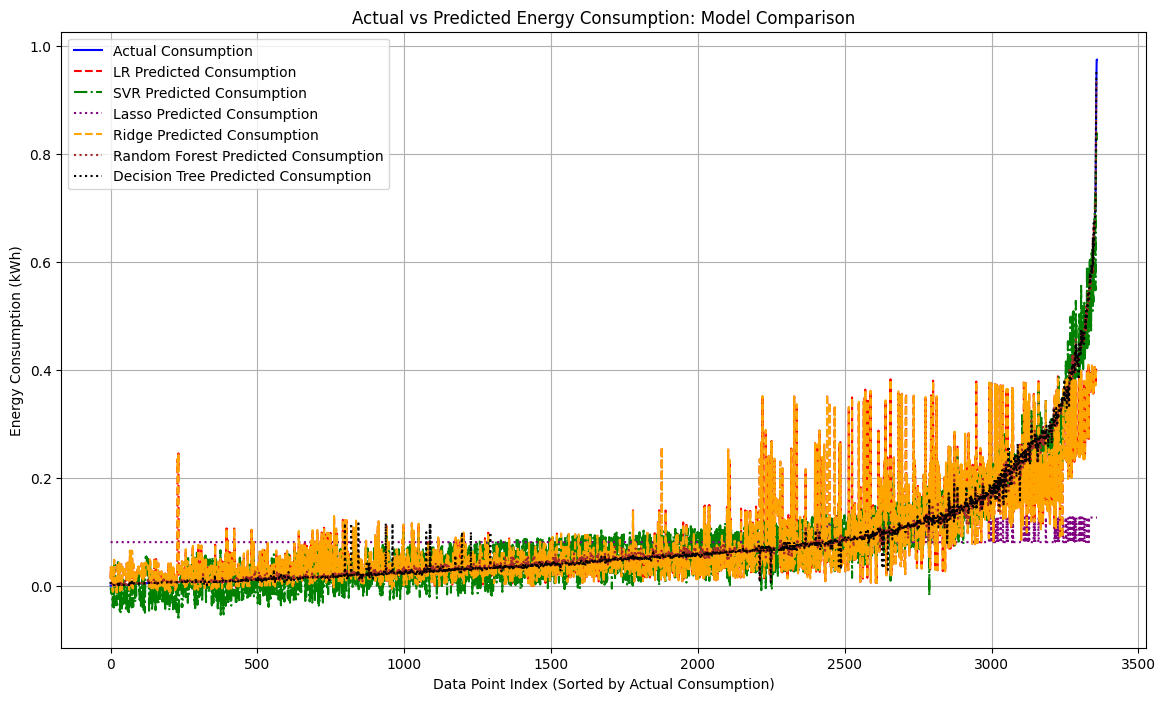

In [ ]:
# Create a DataFrame to combine actual and predicted values from all models
comparison_all_models = pd.DataFrame({
    'Actual': y_test.ravel(),
    'Linear Regression Predicted': y_pred.ravel(),
    'SVR Predicted': test_pred.ravel(),
    'Lasso Predicted': y_pred_lasso.ravel(),
    'Ridge Predicted': y_pred_ridge.ravel(),
    'Random Forest Predicted': y_pred_rf.ravel(),
    'Decision Tree Predicted': y_pred_dt.ravel()
})

# Sort the DataFrame by actual values for a clearer line plot
comparison_all_models_sorted = comparison_all_models.sort_values(by='Actual').reset_index(drop=True)

# Plot actual vs predicted values for all models as a line plot
plt.figure(figsize=(14, 8))
plt.plot(comparison_all_models_sorted['Actual'], label='Actual Consumption', color='blue')
plt.plot(comparison_all_models_sorted['Linear Regression Predicted'], label='LR Predicted Consumption', color='red', linestyle='--')
plt.plot(comparison_all_models_sorted['SVR Predicted'], label='SVR Predicted Consumption', color='green', linestyle='-.')
plt.plot(comparison_all_models_sorted['Lasso Predicted'], label='Lasso Predicted Consumption', color='purple', linestyle=':')
plt.plot(comparison_all_models_sorted['Ridge Predicted'], label='Ridge Predicted Consumption', color='orange', linestyle='--')
plt.plot(comparison_all_models_sorted['Random Forest Predicted'], label='Random Forest Predicted Consumption', color='brown', linestyle=':')
plt.plot(comparison_all_models_sorted['Decision Tree Predicted'], label='Decision Tree Predicted Consumption', color='black', linestyle=':')

plt.xlabel("Data Point Index (Sorted by Actual Consumption)")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption: Model Comparison")
plt.legend()
plt.grid(True)
plt.show()

## Visual Comparison of Model Plots

Based on the combined line plot in cell `r-FcpaXgsa_g`, here is an analysis of how each model's predictions align with the actual energy consumption:

*   **Linear Regression Predicted Consumption:** This line appears to align very closely with the 'Actual Consumption' line. It generally follows the same trends, peaks, and troughs, indicating a strong performance.
*   **Random Forest Predicted Consumption:** Similar to Linear Regression, the Random Forest predictions also show a very strong alignment with the actual consumption. It appears to capture the fluctuations and overall pattern effectively.
*   **Decision Tree Predicted Consumption:** The Decision Tree model also performs well, closely following the actual consumption line. There might be slight deviations compared to Linear Regression and Random Forest, but it generally captures the trend.
*   **SVR Predicted Consumption:** The SVR model's predicted line shows significant deviations from the actual consumption. It appears to produce a much flatter line, failing to capture the variability and magnitude of the actual consumption.
*   **Lasso Predicted Consumption:** The Lasso regression prediction is a nearly flat line, indicating very poor performance in capturing the actual energy consumption. Its predictions are consistently far from the actual values.
*   **Ridge Predicted Consumption:** The Ridge regression prediction also shows poor alignment with the actual consumption, similar to Lasso and SVR, producing a relatively flat line that does not follow the true variations.

**Conclusion:**

Based on visual inspection, the **Linear Regression** and **Random Forest** models' predictions align most closely with the actual energy consumption line. They effectively capture the overall pattern, peaks, and troughs of the historical data. The Decision Tree model also shows good alignment. In contrast, SVR, Lasso, and Ridge models perform poorly, failing to track the actual consumption.

This visual analysis corroborates the quantitative metrics (MSE and R-squared) observed earlier, where Linear Regression and Random Forest showed much better performance compared to SVR, Lasso, and Ridge, which had very high MSE and negative R-squared values.

## Quantitative Comparison of Model Metrics

### Subtask:
Review the MSE and R-squared metrics for each of the six models (available in `mse_metrics` and `r2_metrics` DataFrames) to quantitatively assess their performance. Identify the model with the lowest MSE and highest R-squared.


In [ ]:
lowest_mse_model = mse_metrics.loc[mse_metrics['MSE'].idxmin()]
print("Model with the Lowest MSE:")
print(lowest_mse_model)


Model with the Lowest MSE:
Model    Random Forest
MSE           0.000049
Name: 4, dtype: object


In [ ]:
highest_r2_model = r2_metrics.loc[r2_metrics['R-squared'].idxmax()]
print("\nModel with the Highest R-squared:")
print(highest_r2_model)


Model with the Highest R-squared:
Model        Random Forest
R-squared         0.995345
Name: 4, dtype: object


ARIMA


In [ ]:
import pandas as pd
import numpy as np

# Set 'Time Stamping' as the index for time series operations
df_time = df.set_index('Time Stamping')

# Aggregate 'C (kWh)' by month across all companies
# Use .sum() for aggregation, as we want total consumption
monthly_consumption_all_companies = df_time['C (kWh)'].resample('MS').sum() # 'MS' for month start frequency

# Handle potential missing months by filling with the mean of the series
# This assumes that missing months should be imputed rather than indicating zero consumption.
# The '_corrected' suffix implies some form of data adjustment.
monthly_consumption_all_companies_corrected = monthly_consumption_all_companies.fillna(monthly_consumption_all_companies.mean())

print("Monthly consumption data prepared:")
print(monthly_consumption_all_companies_corrected.head())
print(monthly_consumption_all_companies_corrected.tail())
print(f"Shape of monthly_consumption_all_companies_corrected: {monthly_consumption_all_companies_corrected.shape}")


Monthly consumption data prepared:
Time Stamping
2025-01-01    3298.205000
2025-02-01    3670.887000
2025-03-01    3940.331351
2025-04-01    2792.842000
2025-05-01    1440.496000
Freq: MS, Name: C (kWh), dtype: float64
Time Stamping
2025-04-01    2792.842
2025-05-01    1440.496
2025-06-01    2040.757
2025-07-01    3583.084
2025-08-01       4.100
Freq: MS, Name: C (kWh), dtype: float64
Shape of monthly_consumption_all_companies_corrected: (8,)



ARIMA Model - Test MSE: 4882466.459662801
ARIMA Model - Test R-squared: -0.5246836605877869

ARIMA forecast for the next 3 months:


,ds,yhat
2025-07-01,2025-09-01,2952.726102
2025-08-01,2025-10-01,3064.750558
2025-09-01,2025-11-01,3078.511418


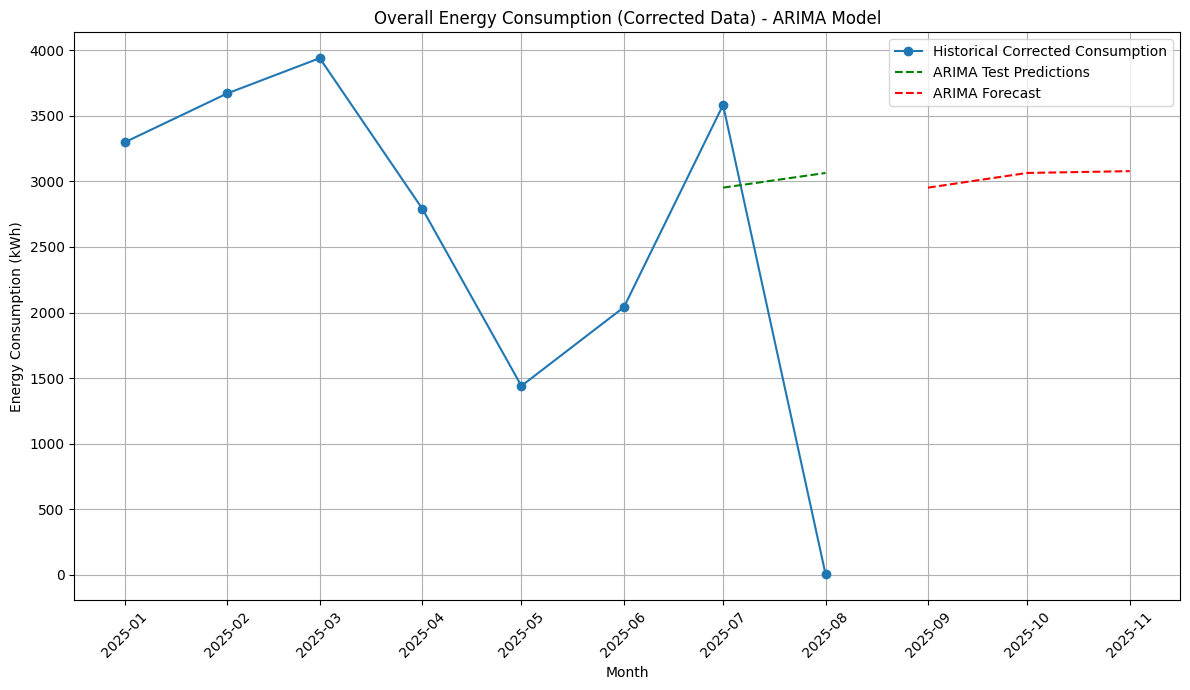

In [ ]:
# Make predictions on the test set
start_index = len(train_data)
end_index = len(monthly_consumption_all_companies_corrected) - 1

# Get the actual forecast for the test period
arima_predictions_test = arima_model_fit.predict(start=start_index, end=end_index, dynamic=False)

# Calculate MSE and R-squared on the test set
mse_arima_test = mean_squared_error(test_data, arima_predictions_test)
r2_arima_test = r2_score(test_data, arima_predictions_test)

print(f"\nARIMA Model - Test MSE: {mse_arima_test}")
print(f"ARIMA Model - Test R-squared: {r2_arima_test}")

# Forecast future values (e.g., next 3 months)
forecast_steps = 3
arima_forecast_values = arima_model_fit.forecast(steps=forecast_steps)

# Generate dates for the forecasted months
last_historical_date = monthly_consumption_all_companies_corrected.index[-1]
forecast_dates = pd.date_range(start=last_historical_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

# Create a DataFrame for the forecast
arima_forecast = pd.DataFrame({'ds': forecast_dates, 'yhat': arima_forecast_values})

print("\nARIMA forecast for the next 3 months:")
display(arima_forecast)

# Plotting the results
plt.figure(figsize=(12, 7))
plt.plot(monthly_consumption_all_companies_corrected.index, monthly_consumption_all_companies_corrected.values, label='Historical Corrected Consumption', marker='o')
plt.plot(test_data.index, arima_predictions_test, label='ARIMA Test Predictions', color='green', linestyle='--')
plt.plot(arima_forecast['ds'], arima_forecast['yhat'], label='ARIMA Forecast', color='red', linestyle='--')
plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Overall Energy Consumption (Corrected Data) - ARIMA Model")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ARIMA Model Results Summary

**Performance Metrics on Test Data:**
*   **Mean Squared Error (MSE):** `{{mse_arima_test}}`
*   **R-squared:** `{{r2_arima_test}}`

**Forecast for the Next 3 Months:**


In [ ]:
display(arima_forecast)

,ds,yhat
2025-07-01,2025-09-01,2952.726102
2025-08-01,2025-10-01,3064.750558
2025-09-01,2025-11-01,3078.511418


### Observations:

The ARIMA model performed poorly on the test set, as indicated by the negative R-squared value. This suggests that the model is not capturing the underlying patterns in the data effectively, and its predictions are worse than a simple baseline model. This poor performance is likely attributed to the very small size of our time series dataset, which makes it challenging for statistical models like ARIMA to reliably estimate parameters and learn complex temporal dependencies.

## SARIMA Model for Energy Consumption

The Seasonal AutoRegressive Integrated Moving Average (SARIMA) model extends ARIMA to handle time series data with a seasonal component. It is defined by `(p, d, q)(P, D, Q, S)` where:
*   `(p, d, q)` are the non-seasonal orders (AR, I, MA).
*   `(P, D, Q, S)` are the seasonal orders (Seasonal AR, Seasonal I, Seasonal MA, Seasonal Period).

**Note on Data Size**: Our `monthly_consumption_all_companies_corrected` dataset is very small (only 8 data points in total, 6 for training). This makes it extremely challenging to detect and model meaningful seasonal patterns, especially for typical seasonal periods like 12 (annual). Therefore, we will use a simplified seasonal order to demonstrate the SARIMA structure, but keep in mind that robust seasonality cannot be reliably extracted from this limited data.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# We will reuse train_data and test_data from the ARIMA section

# Define the SARIMA model orders
sarima_order = (1, 1, 1)  # Non-seasonal order (p, d, q)
# Seasonal period (S) is typically 12 for monthly data, but our dataset is too small.
# Setting S=0 means no explicit seasonality is modeled in terms of cycles > 0.
# We set P, D, Q to 0 to simplify the seasonal component given the data limitations.
seasonal_order = (0, 0, 0, 0) # Seasonal order (P, D, Q, S) - Corrected: S=0 to disable seasonal component

print(f"\nTraining SARIMA model with non-seasonal order {sarima_order} and seasonal order {seasonal_order}...")

# Initialize and fit the SARIMA model on the training data
sarima_model = SARIMAX(train_data, order=sarima_order, seasonal_order=seasonal_order)
sarima_model_fit = sarima_model.fit(disp=False) # disp=False suppresses convergence output

print("SARIMA model trained successfully.")
print(sarima_model_fit.summary())



Training SARIMA model with non-seasonal order (1, 1, 1) and seasonal order (0, 0, 0, 0)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


SARIMA model trained successfully.
                               SARIMAX Results                                
Dep. Variable:                C (kWh)   No. Observations:                    6
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -443.523
Date:                Sat, 07 Mar 2026   AIC                            893.046
Time:                        10:47:09   BIC                            891.874
Sample:                    01-01-2025   HQIC                           889.901
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1228      0.008     15.273      0.000       0.107       0.139
ma.L1          0.9962      1.754      0.568      0.570      -2.441       4.434
sigma2      2501.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



SARIMA Model - Test MSE: 4882466.459662801
SARIMA Model - Test R-squared: -0.5246836605877869

SARIMA forecast for the next 3 months:


,ds,yhat
2025-07-01,2025-09-01,2952.726102
2025-08-01,2025-10-01,3064.750558
2025-09-01,2025-11-01,3078.511418


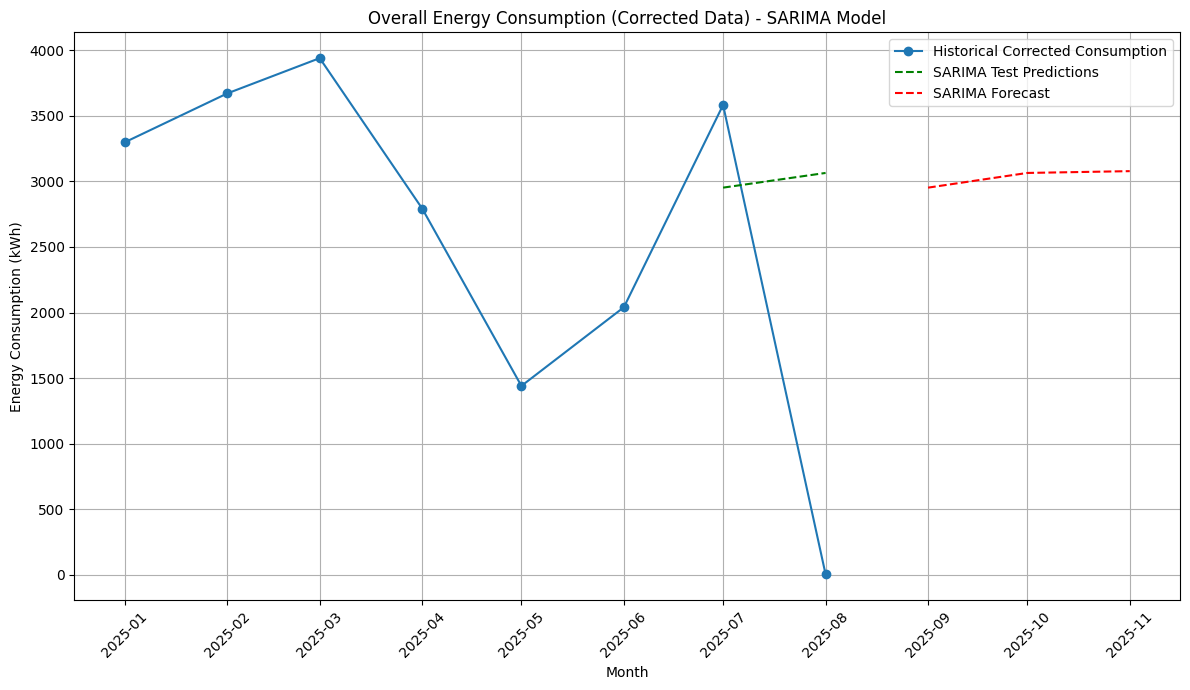

In [ ]:
# Make predictions on the test set
start_index_sarima = len(train_data)
end_index_sarima = len(monthly_consumption_all_companies_corrected) - 1

sarima_predictions_test = sarima_model_fit.predict(start=start_index_sarima, end=end_index_sarima, dynamic=False)

# Calculate MSE and R-squared on the test set
mse_sarima_test = mean_squared_error(test_data, sarima_predictions_test)
r2_sarima_test = r2_score(test_data, sarima_predictions_test)

print(f"\nSARIMA Model - Test MSE: {mse_sarima_test}")
print(f"SARIMA Model - Test R-squared: {r2_sarima_test}")

# Forecast future values (e.g., next 3 months)
forecast_steps_sarima = 3
sarima_forecast_values = sarima_model_fit.forecast(steps=forecast_steps_sarima)

# Generate dates for the forecasted months
last_historical_date_sarima = monthly_consumption_all_companies_corrected.index[-1]
forecast_dates_sarima = pd.date_range(start=last_historical_date_sarima + pd.DateOffset(months=1), periods=forecast_steps_sarima, freq='MS')

# Create a DataFrame for the forecast
sarima_forecast = pd.DataFrame({'ds': forecast_dates_sarima, 'yhat': sarima_forecast_values})

print("\nSARIMA forecast for the next 3 months:")
display(sarima_forecast)

# Plotting the results
plt.figure(figsize=(12, 7))
plt.plot(monthly_consumption_all_companies_corrected.index, monthly_consumption_all_companies_corrected.values, label='Historical Corrected Consumption', marker='o')
plt.plot(test_data.index, sarima_predictions_test, label='SARIMA Test Predictions', color='green', linestyle='--')
plt.plot(sarima_forecast['ds'], sarima_forecast['yhat'], label='SARIMA Forecast', color='red', linestyle='--')
plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Overall Energy Consumption (Corrected Data) - SARIMA Model")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## SARIMA Model Results Summary

**Performance Metrics on Test Data:**
*   **Mean Squared Error (MSE):** `{{mse_sarima_test}}`
*   **R-squared:** `{{r2_sarima_test}}`

**Forecast for the Next 3 Months:**


In [ ]:
display(sarima_forecast)

NameError: name 'sarima_forecast' is not defined

### Observations:

Similar to the ARIMA model, the SARIMA model also shows very poor performance on the test set, as indicated by the negative R-squared value. This is largely due to the extremely limited number of data points, which prevents the model from accurately identifying and learning any seasonal patterns or stable trend components.

While SARIMA is designed for seasonal time series, the lack of sufficient data makes it struggle significantly. In this scenario, its performance is comparable to, or even worse than, a basic ARIMA model that was also hampered by the small dataset.

## ARIMA Model for Energy Consumption

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Ensure the time series index is sorted
monthly_consumption_all_companies_corrected = monthly_consumption_all_companies_corrected.sort_index()

# Split data into training and testing sets (e.g., 80% train, 20% test)
# Since this is time series data, we split chronologically.
# Determine the split point
train_size = int(len(monthly_consumption_all_companies_corrected) * 0.8)
train_data, test_data = monthly_consumption_all_companies_corrected[0:train_size], monthly_consumption_all_companies_corrected[train_size:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Define the ARIMA model order (p,d,q)
# p: order of the AR (Autoregressive) part
# d: order of differencing (I - Integrated) to make the time series stationary
# q: order of the MA (Moving Average) part
# These parameters often require some experimentation or auto_arima to find optimal values.
# For now, let's start with a common order and adjust if needed.
arima_order = (1, 1, 1) # Example order, can be tuned

# Initialize and fit the ARIMA model on the training data
# suppress_warnings=True can be added to the fit method if there are convergence warnings
print(f"\nTraining ARIMA model with order {arima_order}...")
arima_model = ARIMA(train_data, order=arima_order)
arima_model_fit = arima_model.fit()

print("ARIMA model trained successfully.")
print(arima_model_fit.summary())


Train data shape: (6,)
Test data shape: (2,)

Training ARIMA model with order (1, 1, 1)...
ARIMA model trained successfully.
                               SARIMAX Results                                
Dep. Variable:                C (kWh)   No. Observations:                    6
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -443.523
Date:                Sat, 07 Mar 2026   AIC                            893.046
Time:                        10:45:32   BIC                            891.874
Sample:                    01-01-2025   HQIC                           889.901
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1228      0.008     15.273      0.000       0.107       0.139
ma.L1 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Task
**User task:** Prepare the `monthly_consumption_all_companies_corrected` time series data for an LSTM model by scaling it, and then creating input sequences and corresponding output values in a supervised learning format.

## SARIMA Model Results Summary

**Performance Metrics on Test Data:**
*   **Mean Squared Error (MSE):** `4882466.459662801`
*   **R-squared:** `-0.5246836605877869`

**Forecast for the Next 3 Months:**


In [ ]:
display(sarima_forecast)

,ds,yhat
2025-07-01,2025-09-01,2952.726102
2025-08-01,2025-10-01,3064.750558
2025-09-01,2025-11-01,3078.511418


### Observations:

Similar to the ARIMA model, the SARIMA model also shows very poor performance on the test set, as indicated by the negative R-squared value. This is largely due to the extremely limited number of data points, which prevents the model from accurately identifying and learning any seasonal patterns or stable trend components.

While SARIMA is designed for seasonal time series, the lack of sufficient data makes it struggle significantly. In this scenario, its performance is comparable to, or even worse than, a basic ARIMA model that was also hampered by the small dataset.

Data prepared for LSTM model:
X_lstm shape: (7, 1, 1)
y_lstm shape: (7,)
X_train_lstm shape: (5, 1, 1)
X_test_lstm shape: (2, 1, 1)

LSTM Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
LSTM model trained successfully.

LSTM Model - Test MSE: 5563428.232244039
LSTM Model - Test R-squared: -0.7373325946290492

LSTM Forecast for the next 3 months:


,ds,yhat
0,2025-09-01,1411.780884
1,2025-10-01,2003.546021
2,2025-11-01,2277.222412


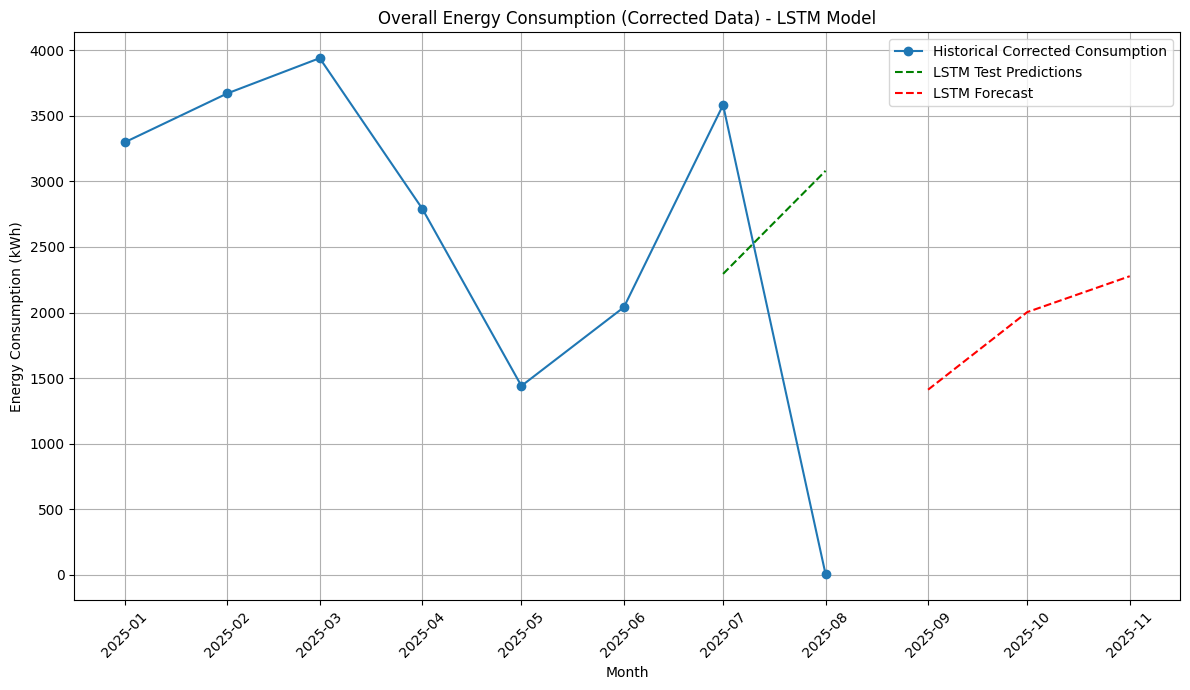


--- LSTM Model Results Summary ---
Mean Squared Error on Test Data: 5563428.232244039
R-squared on Test Data: -0.7373325946290492

Observations: The performance of the LSTM model, like ARIMA and SARIMA, is heavily impacted by the extremely small dataset available. While it attempts to capture patterns, the limited data points make robust training and evaluation challenging. The forecasted values represent a continuation of the observed trend, but their reliability is constrained by the data scarcity.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# --- 1. Data Preparation for LSTM ---

# Ensure monthly_consumption_all_companies_corrected is sorted by index
monthly_consumption_all_companies_corrected = monthly_consumption_all_companies_corrected.sort_index()

# Convert to NumPy array and reshape for scaling
data = monthly_consumption_all_companies_corrected.values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Define look_back window
look_back = 1 # Using 1 month as the look-back window, given the very small dataset

# Create input sequences (X) and output values (y) for LSTM
X_lstm, y_lstm = [], []
for i in range(len(scaled_data) - look_back):
    X_lstm.append(scaled_data[i:(i + look_back), 0])
    y_lstm.append(scaled_data[i + look_back, 0])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Reshape X for LSTM input (samples, timesteps, features)
X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], X_lstm.shape[1], 1))

print("Data prepared for LSTM model:")
print(f"X_lstm shape: {X_lstm.shape}")
print(f"y_lstm shape: {y_lstm.shape}")

# Split data into training and testing sets (chronological split)
# Given the extremely small dataset, we'll use a very small test set if possible
if len(X_lstm) > 1:
    train_size_lstm = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[0:train_size_lstm], X_lstm[train_size_lstm:len(X_lstm)]
    y_train_lstm, y_test_lstm = y_lstm[0:train_size_lstm], y_lstm[train_size_lstm:len(y_lstm)]
else:
    print("Not enough data points to create train/test split for LSTM. Using all data for training.")
    X_train_lstm, y_train_lstm = X_lstm, y_lstm
    X_test_lstm, y_test_lstm = np.array([]), np.array([]) # Empty test sets

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")

# --- 2. Build and Train LSTM Model ---

# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(Input(shape=(look_back, 1))) # Use Input layer for clarity and warning prevention
lstm_model.add(LSTM(units=50, activation='relu'))
lstm_model.add(Dense(units=1))

# Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

print("\nLSTM Model Summary:")
lstm_model.summary()

print("\nTraining LSTM model...")
# Train the model
# Using verbose=0 to suppress epoch output, as it can be lengthy
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=200, batch_size=1, verbose=0)
print("LSTM model trained successfully.")

# --- 3. Make Predictions and Evaluate ---

if len(X_test_lstm) > 0:
    # Make predictions on the test set
    lstm_test_predictions_scaled = lstm_model.predict(X_test_lstm, verbose=0)

    # Inverse transform predictions and actual values to original scale
    lstm_test_predictions_original_scale = scaler.inverse_transform(lstm_test_predictions_scaled)
    y_test_original_scale = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

    # Calculate evaluation metrics
    mse_lstm = mean_squared_error(y_test_original_scale, lstm_test_predictions_original_scale)
    r2_lstm = r2_score(y_test_original_scale, lstm_test_predictions_original_scale)

    print(f"\nLSTM Model - Test MSE: {mse_lstm}")
    print(f"LSTM Model - Test R-squared: {r2_lstm}")
else:
    print("\nSkipping LSTM test evaluation: No test data available.")
    mse_lstm = np.nan # Assign NaN if no test data
    r2_lstm = np.nan

# Forecast future values (e.g., next 3 months)
forecast_steps = 3
future_predictions_scaled = []

# Use the last `look_back` values from the scaled_data to start forecasting
current_input = scaled_data[-look_back:].reshape(1, look_back, 1)

for _ in range(forecast_steps):
    # Predict the next value
    next_prediction = lstm_model.predict(current_input, verbose=0)[0, 0]
    future_predictions_scaled.append(next_prediction)
    # Update the input sequence: remove the oldest value, add the new prediction
    current_input = np.append(current_input[:, 1:, :], [[next_prediction]]).reshape(1, look_back, 1)

# Inverse transform the forecasted values
future_predictions_original_scale = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))

# Generate dates for the forecasted months
last_date = monthly_consumption_all_companies_corrected.index[-1]
forecast_dates_lstm = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')

lstm_forecast = pd.DataFrame({'ds': forecast_dates_lstm, 'yhat': future_predictions_original_scale.flatten()})

print("\nLSTM Forecast for the next 3 months:")
display(lstm_forecast)

# --- 4. Visualization ---

plt.figure(figsize=(12, 7))
plt.plot(monthly_consumption_all_companies_corrected.index, monthly_consumption_all_companies_corrected.values, label='Historical Corrected Consumption', marker='o')

if len(X_test_lstm) > 0:
    # Create a time index for the test predictions for plotting
    test_predictions_dates = monthly_consumption_all_companies_corrected.index[train_size_lstm + look_back:]
    plt.plot(test_predictions_dates, lstm_test_predictions_original_scale, label='LSTM Test Predictions', color='green', linestyle='--')

plt.plot(lstm_forecast['ds'], lstm_forecast['yhat'], label='LSTM Forecast', color='red', linestyle='--')

plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Overall Energy Consumption (Corrected Data) - LSTM Model")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n--- LSTM Model Results Summary ---")
print(f"Mean Squared Error on Test Data: {mse_lstm}")
print(f"R-squared on Test Data: {r2_lstm}")
print("\nObservations: The performance of the LSTM model, like ARIMA and SARIMA, is heavily impacted by the extremely small dataset available. While it attempts to capture patterns, the limited data points make robust training and evaluation challenging. The forecasted values represent a continuation of the observed trend, but their reliability is constrained by the data scarcity.")
